# R&E 연구 검증 방법론

연구에서 데이터를 분석할 때, 가장 먼저 물어야 할 질문은 이것이다:

1. **변수가 몇 개인가?** (1개? 2개? 3개 이상?)
2. **각 변수가 어떤 타입인가?** (수치형? 범주형?)

이 두 질문의 답에 따라 쓸 수 있는 분석 방법이 결정된다.

```
변수 개수
|
|-- 1-Feature (단변량)
|     |-- 수치형: 기술통계, 히스토그램, 정규성 검정, KDE, 이상치 탐지
|     |-- 범주형: 빈도표, 막대그래프
|     |-- 시계열: 추세 분해, 정상성 검정, 자기상관
|
|-- 2-Feature (이변량)
|     |-- 수치 vs 수치: 상관분석, 회귀분석
|     |-- 범주 vs 수치: t-test (2그룹), ANOVA (3+그룹)
|     |-- 범주 vs 범주: 카이제곱 검정
|     |-- 비모수: Spearman, Mann-Whitney, Kruskal-Wallis
|
|-- 3+ Feature (다변량)
      |-- 차원축소: PCA, t-SNE
      |-- 군집화: K-Means, DBSCAN, 계층적
      |-- 다중회귀: 다중선형회귀 + VIF
      |-- 분류: Random Forest, Logistic Regression
      |-- 해석: Feature Importance, SHAP
```

---

### 데이터셋: Palmer Penguins

| 변수 | 타입 | 설명 |
|------|------|------|
| species | 범주형 (3종) | Adelie, Chinstrap, Gentoo |
| island | 범주형 (3곳) | Biscoe, Dream, Torgersen |
| bill_length_mm | 수치형 | 부리 길이 (mm) |
| bill_depth_mm | 수치형 | 부리 깊이 (mm) |
| flipper_length_mm | 수치형 | 날개 길이 (mm) |
| body_mass_g | 수치형 | 체중 (g) |
| sex | 범주형 (2종) | Male, Female |

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = sns.load_dataset('penguins').dropna()
print(f'데이터 수: {len(df)}')
df.head()

---
# Part 1. 1-Feature (단변량 분석)

변수 하나를 골라서, 그 변수가 **어떻게 생겼는지** 파악하는 단계.  
모든 분석의 출발점이고, 논문에서는 보통 Table 1에 해당한다.

## 1-A. 수치형 변수 1개

수치형 변수 하나를 골랐을 때 할 수 있는 것들:

| 방법 | 알 수 있는 것 |
|------|-------------|
| 기술통계 (mean, std, min, max) | 중심, 퍼짐, 범위 |
| 히스토그램 | 분포의 모양 (치우침, 봉우리 수) |
| 박스플롯 | 사분위수, 이상치 |
| 정규성 검정 | 정규분포를 따르는가 |

### Agent 지시 예시
> "body_mass_g 변수의 기술통계를 구하고, 히스토그램과 박스플롯을 그려줘. 정규성 검정(Shapiro-Wilk)도 해줘."

In [ ]:
# 기술통계
target = df['body_mass_g']
print('=== body_mass_g 기술통계 ===')
print(f'  평균(mean):     {target.mean():.1f}')
print(f'  중앙값(median): {target.median():.1f}')
print(f'  표준편차(std):  {target.std():.1f}')
print(f'  최솟값(min):    {target.min():.1f}')
print(f'  최댓값(max):    {target.max():.1f}')

In [ ]:
# 시각화: 히스토그램 + 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Histogram: body_mass_g')
axes[0].set_xlabel('Body Mass (g)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(target, vert=True)
axes[1].set_title('Boxplot: body_mass_g')
axes[1].set_ylabel('Body Mass (g)')

plt.tight_layout()
plt.show()

In [ ]:
# 정규성 검정 (Shapiro-Wilk)
# 많은 통계 검정이 "정규분포를 따른다"는 가정을 깔고 있다.
# 이 가정이 맞는지 먼저 확인해야 한다.
stat, p_value = stats.shapiro(target)
print(f'Shapiro-Wilk test')
print(f'  statistic: {stat:.4f}')
print(f'  p-value:   {p_value:.4f}')
print()
if p_value < 0.05:
    print('  -> p < 0.05: 정규분포를 따르지 않는다.')
    print('     (비모수 검정을 고려해야 할 수 있음)')
else:
    print('  -> p >= 0.05: 정규분포를 따른다고 볼 수 있다.')

#### 왜 정규성이 중요한가?

t-test, ANOVA 등 많이 쓰는 검정들은 "데이터가 정규분포를 따른다"는 가정 위에 만들어졌다.  
이 가정이 깨지면 검정 결과를 신뢰하기 어렵다.

| 정규분포를 따르면 | 정규분포를 따르지 않으면 |
|-----------------|---------------------|
| t-test 사용 가능 | Mann-Whitney U 검정 (비모수) |
| ANOVA 사용 가능 | Kruskal-Wallis 검정 (비모수) |
| 피어슨 상관 | 스피어만 상관 |

## 1-B. 범주형 변수 1개

범주형 변수 하나를 골랐을 때 할 수 있는 것들:

| 방법 | 알 수 있는 것 |
|------|-------------|
| 빈도표 | 각 범주에 몇 개씩 있는가 |
| 막대그래프 | 빈도의 시각적 비교 |
| 비율 | 전체에서 각 범주의 비중 |

### Agent 지시 예시
> "species 변수의 빈도와 비율을 구하고, 막대그래프로 그려줘."

            빈도     비율
species              
Adelie     146  43.8%
Gentoo     119  35.7%
Chinstrap   68  20.4%



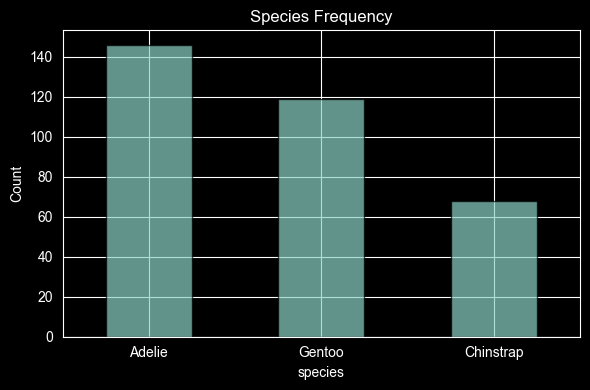

In [2]:
# 빈도표 + 비율
freq = df['species'].value_counts()
ratio = df['species'].value_counts(normalize=True)

summary = pd.DataFrame({'빈도': freq, '비율': ratio.map(lambda x: f'{x:.1%}')})
print(summary)
print()

# 막대그래프
plt.figure(figsize=(6, 4))
freq.plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Species Frequency')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 1-C. 고급 단변량: KDE, 이상치 탐지, 분포 적합

실제 연구에서는 히스토그램 너머의 분석이 필요하다.

| 방법 | 질문 | 핵심 |
|------|------|------|
| KDE (커널 밀도 추정) | 분포의 진짜 모양은? | 히스토그램의 연속 버전. 봉우리 수, 비대칭성 시각화 |
| 이상치 탐지 (IQR) | 비정상적 값이 있는가? | Q1-1.5*IQR ~ Q3+1.5*IQR 범위 밖 |
| 이상치 탐지 (Z-score) | 평균에서 극단적으로 먼 값? | \|z\| > 3이면 이상치 의심 |
| 분포 적합 | 어떤 이론적 분포를 따르는가? | 정규, 로그정규, 지수, 감마 등에 적합 |
| 부트스트랩 | 모수의 신뢰구간은? | 표본을 반복 추출하여 추정치의 불확실성 계산 |

### Agent 지시 예시
> "body_mass_g의 KDE를 그리고, IQR 방법과 Z-score 방법으로 이상치를 찾아줘.  
> 정규분포, 로그정규분포, 감마분포 중 어느 것에 가장 잘 적합되는지도 확인해줘."

---
# Part 2. 2-Feature (이변량 분석)

변수 2개를 골라서 **둘 사이에 관계가 있는지** 분석하는 단계.  
연구의 핵심. "X가 Y에 영향을 미치는가?"에 답한다.

두 변수의 타입 조합에 따라 사용할 방법이 완전히 달라진다:

```
2-Feature
|
|-- [2-A] 수치 vs 수치  ->  상관분석, 회귀분석
|-- [2-B] 범주 vs 수치  ->  t-test, ANOVA
|-- [2-C] 범주 vs 범주  ->  카이제곱 검정
```

---
## 2-A. 수치 vs 수치

두 변수가 모두 숫자일 때. "하나가 올라가면 다른 것도 올라가는가?"

### 사용 도구

| 방법 | 질문 | 결과 |
|------|------|------|
| 산점도 | 관계가 있어 보이는가? | 시각적 판단 |
| 상관분석 (r) | 관계의 강도와 방향은? | -1 ~ +1 |
| 회귀분석 | X가 1 늘면 Y가 얼마나 변하는가? | 회귀식, R-squared |

### Agent 지시 예시
> "flipper_length_mm와 body_mass_g의 산점도를 그리고, 피어슨 상관계수를 구해줘.  
> 상관이 유의하면 선형 회귀도 해서 회귀식과 R-squared를 알려줘."

In [ ]:
# 산점도: 먼저 눈으로 확인
plt.figure(figsize=(7, 5))
plt.scatter(df['flipper_length_mm'], df['body_mass_g'], alpha=0.5)
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Flipper Length vs Body Mass')
plt.show()

In [ ]:
# 상관분석
r, p = stats.pearsonr(df['flipper_length_mm'], df['body_mass_g'])
print('=== 상관분석: flipper_length vs body_mass ===')
print(f'  Pearson r: {r:.3f}')
print(f'  p-value:   {p:.2e}')
print()

# 해석 기준
strength = '약한' if abs(r) < 0.3 else ('중간' if abs(r) < 0.7 else '강한')
direction = '양의' if r > 0 else '음의'
print(f'  -> {strength} {direction} 상관 (|r| = {abs(r):.3f})')
if p < 0.05:
    print(f'  -> 통계적으로 유의 (p < 0.05)')

In [ ]:
# 회귀분석: 상관이 유의하므로 "얼마나"를 구체적으로 알아본다
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error

X = df[['flipper_length_mm']]
y = df['body_mass_g']

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

print('=== 회귀분석 ===')
print(f'  회귀식: body_mass = {model.coef_[0]:.2f} * flipper_length + ({model.intercept_:.2f})')
print(f'  R-squared: {r2_score(y, y_pred):.3f}')
print(f'  RMSE: {root_mean_squared_error(y, y_pred):.1f}g')
print()
print(f'  해석: 날개가 1mm 길어지면 체중이 약 {model.coef_[0]:.1f}g 증가하는 경향.')
print(f'        모델이 체중 변동의 {r2_score(y, y_pred)*100:.1f}%를 설명한다.')

# 회귀선 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X, y, alpha=0.4, label='data')
plt.plot(X, y_pred, color='red', linewidth=2, label='regression')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title(f'Linear Regression (R2={r2_score(y, y_pred):.3f})')
plt.legend()
plt.show()

### 상관 vs 회귀 - 뭐가 다른가?

| | 상관분석 | 회귀분석 |
|--|---------|--------|
| 질문 | 관계가 **있는가**? 얼마나 강한가? | X로 Y를 **예측**할 수 있는가? |
| 방향성 | X<->Y 대칭 (누가 원인인지 모름) | X->Y 방향이 있음 |
| 결과물 | 상관계수 r (-1~1) | 회귀식 (y = ax + b), R-squared |
| 용도 | 탐색적 분석 | 예측, 영향력 정량화 |

### 주의: 상관 != 인과

"아이스크림 판매량과 익사 사고는 r = 0.9"  
아이스크림이 익사를 유발하는가? 아니다. 둘 다 **기온(제3변수)** 때문이다.

상관에서 인과를 주장하려면:
1. 시간적 선후관계 (A가 B보다 먼저)
2. 제3의 변수 통제
3. 이론적 메커니즘 설명 가능

### 상관행렬: 수치형 변수 전체를 한눈에

### Agent 지시 예시
> "수치형 변수 전체의 상관행렬을 구하고 히트맵으로 그려줘. 가장 강한 상관 쌍 3개를 알려줘."

In [ ]:
# 상관행렬 히트맵
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 2-B. 범주 vs 수치

"그룹에 따라 숫자 값이 다른가?"  
범주(그룹)가 몇 개인지에 따라 방법이 갈린다.

```
범주 vs 수치
|
|-- 그룹 2개 -> t-test
|-- 그룹 3개+ -> ANOVA + 사후검정
```

### 핵심 개념
"눈으로 보니 다른 것 같다"는 근거가 안 된다.  
검정은 **"이 차이가 우연히 생길 수 있는 정도인가"**를 수치로 판단한다.

### 2-B-1. t-test (그룹 2개)

| 종류 | 상황 |
|------|------|
| 독립표본 t-test | 서로 다른 두 그룹 비교 (예: 남 vs 여) |
| 대응표본 t-test | 같은 대상의 전후 비교 (예: 투약 전 vs 후) |

### Agent 지시 예시
> "수컷과 암컷 펭귄의 체중에 유의한 차이가 있는지 독립표본 t-test 해줘.  
> p-value와 Cohen's d(효과 크기)도 보고해줘."

In [ ]:
# 시각화로 먼저 확인
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='sex', y='body_mass_g')
plt.title('Body Mass by Sex')
plt.show()

In [ ]:
# 독립표본 t-test: 수컷 vs 암컷 체중
male = df[df['sex'] == 'Male']['body_mass_g']
female = df[df['sex'] == 'Female']['body_mass_g']

t_stat, p_value = stats.ttest_ind(male, female)

print('=== t-test: Male vs Female body_mass_g ===')
print(f'  Male   평균: {male.mean():.1f}g  (n={len(male)})')
print(f'  Female 평균: {female.mean():.1f}g  (n={len(female)})')
print(f'  차이: {male.mean() - female.mean():.1f}g')
print(f'  t-statistic: {t_stat:.3f}')
print(f'  p-value: {p_value:.2e}')
print()
if p_value < 0.05:
    print('  -> 유의한 차이가 있다 (p < 0.05)')
else:
    print('  -> 유의한 차이 증거 부족 (p >= 0.05)')

In [ ]:
# 효과 크기 (Cohen's d)
# p-value: "차이가 있는가?" (Yes/No)
# Cohen's d: "차이가 얼마나 큰가?" (크기)
# 둘 다 보고해야 완전한 분석이다.

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std

d = cohens_d(male, female)
print(f"Cohen's d: {d:.3f}")
print()
# |d| < 0.2: 작음 / 0.2~0.8: 중간 / > 0.8: 큼
size = '작음' if abs(d) < 0.2 else ('중간' if abs(d) < 0.8 else '큼')
print(f'  -> 효과 크기: {size}')

#### p-value 올바르게 이해하기

**p-value란**: "차이가 없다고 가정했을 때, 이 정도 결과가 우연히 나올 확률"

| 흔한 오해 | 현실 |
|-----------|------|
| "효과가 있을 확률이 95%" | p-value는 그런 뜻이 아니다 |
| "p가 작을수록 효과가 크다" | 아니다. 효과의 크기는 Cohen's d로 본다 |
| "p > 0.05면 차이가 없다" | 없다고 증명된 게 아니라 증거가 부족한 것 |

### 2-B-2. ANOVA (그룹 3개 이상)

그룹이 3개 이상이면 t-test를 여러 번 하면 **안 된다**.  
비교 횟수가 늘수록 우연히 유의한 결과가 나올 확률이 쌓인다. (다중비교 문제)

ANOVA는 "이 그룹들 중 적어도 하나가 다른가?"를 한 번에 검정한다.  
유의하면 -> **사후검정(Tukey)**으로 어떤 쌍이 다른지 추가 확인.

### Agent 지시 예시
> "세 종의 펭귄의 부리 길이에 유의한 차이가 있는지 ANOVA로 검정해줘.  
> 유의하면 Tukey 사후검정으로 어떤 종 사이에 차이가 있는지도 알려줘."

In [ ]:
# 시각화로 먼저 확인
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='species', y='flipper_length_mm')
plt.title('Flipper Length by Species')
plt.show()

In [ ]:
# One-way ANOVA
adelie = df[df['species'] == 'Adelie']['flipper_length_mm']
chinstrap = df[df['species'] == 'Chinstrap']['flipper_length_mm']
gentoo = df[df['species'] == 'Gentoo']['flipper_length_mm']

f_stat, p_value = stats.f_oneway(adelie, chinstrap, gentoo)

print('=== ANOVA: species -> flipper_length_mm ===')
print(f'  Adelie:    {adelie.mean():.1f}mm (n={len(adelie)})')
print(f'  Chinstrap: {chinstrap.mean():.1f}mm (n={len(chinstrap)})')
print(f'  Gentoo:    {gentoo.mean():.1f}mm (n={len(gentoo)})')
print(f'  F-statistic: {f_stat:.3f}')
print(f'  p-value: {p_value:.2e}')
print()
if p_value < 0.05:
    print('  -> 적어도 한 쌍의 종 간에 유의한 차이가 있다.')

In [ ]:
# 사후검정 (Tukey HSD): 어떤 쌍이 다른가?
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(df['flipper_length_mm'], df['species'], alpha=0.05)
print(tukey)
print()
print('reject=True인 쌍: 해당 두 종 사이에 유의한 차이가 있음')

#### t-test vs ANOVA 선택 기준

| 상황 | 방법 |
|------|------|
| 그룹 2개 | t-test |
| 그룹 3개+ | ANOVA |
| 정규분포 아님 + 그룹 2개 | Mann-Whitney U (비모수) |
| 정규분포 아님 + 그룹 3개+ | Kruskal-Wallis (비모수) |

---
## 2-C. 범주 vs 범주

두 변수가 모두 범주형일 때. "A의 분포가 B에 따라 달라지는가?"

### 사용 도구

| 방법 | 알 수 있는 것 |
|------|-------------|
| 교차표 (crosstab) | 각 조합의 빈도 |
| 카이제곱 검정 | 두 범주 변수가 독립인가, 관계가 있는가 |

### Agent 지시 예시
> "종(species)과 서식 섬(island)의 교차표를 만들고,  
> 카이제곱 독립성 검정으로 두 변수 사이에 관계가 있는지 확인해줘."

In [ ]:
# 교차표
ct = pd.crosstab(df['species'], df['island'])
print('=== 교차표: species x island ===')
print(ct)
print()

# 시각화
ct.plot(kind='bar', figsize=(8, 4), edgecolor='black')
plt.title('Species x Island')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 카이제곱 검정
chi2, p_value, dof, expected = stats.chi2_contingency(ct)

print('=== 카이제곱 독립성 검정 ===')
print(f'  chi2: {chi2:.3f}')
print(f'  p-value: {p_value:.2e}')
print(f'  자유도: {dof}')
print()
if p_value < 0.05:
    print('  -> 종과 섬 사이에 유의한 관계가 있다.')
    print('     (특정 종이 특정 섬에 편중 분포)')
else:
    print('  -> 독립이다 (관계 증거 부족)')

print()
print('참고: 기대빈도 (독립이라면 이렇게 분포했을 것)')
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))

#### 읽는 법
- 교차표에서 0인 칸: 해당 조합이 아예 없음 (강한 편중)
- 기대빈도와 실제빈도의 차이가 클수록 관계가 강함
- 카이제곱 검정은 "관계가 있다"만 알려줌. 인과는 아님.

---
# Part 3. 주의사항과 연구 윤리

도구를 아는 것만큼 **잘못된 사용법**을 아는 것도 중요하다.

## 변인 통제

| 용어 | 역할 | 예시 |
|------|------|------|
| 독립변인 | 내가 의도적으로 바꾸는 것 | 비료의 양 |
| 종속변인 | 그 결과로 변하는 것 (측정 대상) | 식물의 키 |
| 통제변인 | 바뀌면 안 되는 것 (고정) | 물의 양, 햇빛 |

핵심 규칙: **한 번에 하나만 바꾼다.**  
두 가지를 동시에 바꾸면 뭐 때문에 결과가 달라졌는지 알 수 없다.

## 편향 (Bias)

| 종류 | 예시 |
|------|------|
| 선택 편향 | 특정 유형만 골라서 조사 |
| 확증 편향 | 내 가설에 맞는 데이터만 보려는 경향 |
| 생존자 편향 | 살아남은 것만 보고 판단 (탈락자 무시) |

## 절대 하면 안 되는 것

| 이름 | 행위 |
|------|------|
| p-hacking | 유의한 결과 나올 때까지 분석 방법을 바꾸는 것 |
| cherry-picking | 유리한 데이터만 골라서 보고 |
| HARKing | 결과 보고 나서 가설을 만들고, 처음부터 그랬던 척 하는 것 |

---
# 전체 요약: 선택 가이드

```
변수가 몇 개인가?
|
|-- 1개 (단변량)
|     |-- 수치형 -> 기술통계, 히스토그램, 정규성 검정
|     |-- 범주형 -> 빈도표, 막대그래프
|
|-- 2개 (이변량)
      |
      |-- 수치 vs 수치
      |     |-- 관계 유무 -> 상관분석 (Pearson r)
      |     |-- 예측/영향 -> 회귀분석
      |
      |-- 범주 vs 수치
      |     |-- 그룹 2개 -> t-test (+Cohen's d)
      |     |-- 그룹 3개+ -> ANOVA (+Tukey 사후검정)
      |     |-- 정규분포 아님 -> 비모수 검정
      |
      |-- 범주 vs 범주
            |-- 카이제곱 검정 (+교차표)
```

---
# Agent 지시문 모음

아래 문장에서 [ ] 안을 본인 데이터에 맞게 바꿔 사용한다.

### 기술통계
- "[데이터]의 [변수]에 대해 기술통계를 구해줘."
- "[변수]의 분포를 히스토그램으로 그리고 정규성 검정해줘."
- "[그룹변수]별로 [측정변수]의 기술통계를 표로 정리해줘."

### 수치 vs 수치
- "[X변수]와 [Y변수]의 상관계수를 구하고 산점도를 그려줘."
- "[X변수]로 [Y변수]를 예측하는 선형 회귀를 해줘. R-squared와 회귀식 알려줘."
- "수치형 변수 전체의 상관행렬 히트맵을 그려줘."

### 범주 vs 수치
- "[그룹A]와 [그룹B]의 [측정값]에 유의한 차이가 있는지 t-test 해줘. Cohen's d도 구해줘."
- "[3개 그룹]의 [측정값]을 ANOVA로 비교해줘. 유의하면 Tukey 사후검정도 해줘."

### 범주 vs 범주
- "[범주A]와 [범주B]의 교차표를 만들고 카이제곱 검정해줘."

### 전체 분석
- "이 데이터에서 [종속변수]에 영향을 미치는 요인을 찾아줘. 각 변수 타입에 맞는 검정을 골라서 분석해줘."
- "분석 결과를 논문 Table 형식으로 정리해줘."